In [1]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/Users/samantha/QuantUS-Plugins-CEUS/China_Data
/Users/samantha/QuantUS-Plugins-CEUS


## Select Contrast-Enhanced Ultrasound (CEUS) Cine and Parser

In [2]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['avi', 'nifti', 'custom_dicom', 'mp4']


In [3]:
scan_type = 'nifti'

scan_path = '/Users/samantha/Desktop/tul/china data/p9/new_v2/CEUS-24728 S7-2.nii.gz'
scan_loader_kwargs = {
    'transpose': False,
}

In [4]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, scan_path, **scan_loader_kwargs)

## Load Segmentation

Assumes same segmentation for each frame

In [5]:
from src.seg_loading.options import get_seg_loaders

print("Available segmentation loaders:", list(get_seg_loaders().keys()))

Available segmentation loaders: ['nifti', 'load_bolus_mask']


In [6]:
seg_type = 'nifti'

seg_path = '/Users/samantha/Desktop/tul/china data/p9/new_v2/v2_voi.nii.gz'
seg_loader_kwargs = {}

In [7]:
from src.entrypoints import seg_loading_step

seg_data = seg_loading_step(seg_type, image_data, seg_path, scan_path, **seg_loader_kwargs)

## CEUS Quantitative Temporal Curve Analysis

In [8]:
from src.time_series_analysis.options import get_analysis_types, get_required_kwargs

all_analysis_types, all_analysis_funcs = get_analysis_types()
print("Available analysis types:", list(all_analysis_types.keys()))

Available analysis types: ['curves_paramap', 'curves']


In [9]:
analysis_type = 'curves'

print("Available analysis functions:", list(all_analysis_funcs.keys()))

Available analysis functions: ['pyradiomics', 'tic']


In [10]:
analysis_funcs = ['tic']

# Find all required kwargs for the analysis functions
analysis_funcs = analysis_funcs if len(analysis_funcs) else list(all_analysis_funcs[analysis_type].keys())
required_kwargs = get_required_kwargs(analysis_type, analysis_funcs)
print("Required kwargs for current analysis:", required_kwargs)

Required kwargs for current analysis: []


In [ ]:
# Set frame rate (adjust this value to match your actual video fps)
image_data.frame_rate = 1  # e.g., 30 fps

analysis_kwargs = {
    'ax_vox_ovrlp': 50,
    'sag_vox_ovrlp': 50,
    'cor_vox_ovrlp': 50,
    'ax_vox_len': 5.0,
    'sag_vox_len': 5.0,
    'cor_vox_len': 5.0,
}


In [ ]:
import copy
import numpy as np
from tqdm import tqdm
from src.time_series_analysis.curves_paramap.framework import CurvesParamapAnalysis


class VectorizedCurvesParamapAnalysis(CurvesParamapAnalysis):

    def compute_curves(self):
        data = self.image_data.intensities_for_analysis
        is_3d = data.ndim == 4
        if not is_3d and data.ndim != 3:
            raise ValueError('Image data must be either 2D+time or 3D+time.')

        n_frames = data.shape[3] if is_3d else data.shape[0]

        voxel_vol = float(np.prod(self.image_data.pixdim))

        self.curves = []
        for ix, window in tqdm(enumerate(self.windows), desc='Computing curves', total=len(self.windows)):
            entry = {}
            if is_3d:
                ax_start, sag_start, cor_start, ax_end, sag_end, cor_end = window
                entry['Window-Axial Start Pix'] = ax_start
                entry['Window-Sagittal Start Pix'] = sag_start
                entry['Window-Coronal Start Pix'] = cor_start
                entry['Window-Axial End Pix'] = ax_end
                entry['Window-Sagittal End Pix'] = sag_end
                entry['Window-Coronal End Pix'] = cor_end
                window_data = data[sag_start:sag_end+1, cor_start:cor_end+1, ax_start:ax_end+1, :]
                num_voxels = window_data.shape[0] * window_data.shape[1] * window_data.shape[2]
                means = np.exp(window_data / 24.09).reshape(-1, n_frames).mean(axis=0)
            else:
                ax_start, sag_start, ax_end, sag_end = window
                entry['Window-Axial Start Pix'] = ax_start
                entry['Window-Sagittal Start Pix'] = sag_start
                entry['Window-Axial End Pix'] = ax_end
                entry['Window-Sagittal End Pix'] = sag_end
                window_data = data[:, ax_start:ax_end+1, sag_start:sag_end+1]
                num_voxels = window_data.shape[1] * window_data.shape[2]
                means = np.exp(window_data / 24.09).reshape(n_frames, -1).mean(axis=1)

            entry['TIC'] = means.tolist()
            entry['TIC_vol'] = (means * voxel_vol * num_voxels).tolist()
            self.curves.append(entry)

        if self.curves_output_path:
            self.save_curves()


print('VectorizedCurvesParamapAnalysis defined')

In [12]:
from src.entrypoints import analysis_step

analysis_obj = analysis_step(analysis_type, image_data, seg_data, analysis_funcs, **analysis_kwargs)

Computing curves: 100%|██████████| 254/254 [00:01<00:00, 140.03it/s]


In [13]:
import numpy as np

# Get raw image and mask
img = image_data.intensities_for_analysis
mask = seg_data.seg_mask

voxel_vol = float(np.prod(image_data.pixdim))
num_voxels = int(np.sum(mask > 0))

# Log-linearize to match GUI (exp(pixel / 24.09) per voxel, then mean)
tic = []
for t in range(img.shape[3]):
    frame = img[:, :, :, t]
    tic.append(np.exp(frame[mask > 0] / 24.09).mean())
tic = np.array(tic)

# Baseline subtraction (same as GUI)
tic = tic - np.mean(tic[:2])
if np.any(tic < 0):
    tic = tic + np.abs(np.min(tic))
else:
    tic = tic - np.min(tic)

tic_vol = tic * voxel_vol * num_voxels

print(f"pixdim: {image_data.pixdim}")
print(f"voxel_vol: {voxel_vol:.6f} mm³")
print(f"num_voxels: {num_voxels:,}")
print(f"voxelscale (voxel_vol * num_voxels): {voxel_vol * num_voxels:.2f} mm³")
print(f"max(tic): {np.max(tic):.4f}")
print(f"max(tic_vol): {np.max(tic_vol):.4f}")
print(f"ratio max(tic_vol)/max(tic): {np.max(tic_vol)/np.max(tic):.2f}")

# Replace the TIC in the analysis object (restore full time array)
analysis_obj.curves[0]['TIC'] = list(tic)
analysis_obj.curves[0]['TIC_vol'] = list(tic_vol)
fps = image_data.frame_rate if np.isfinite(image_data.frame_rate) else 1.0
analysis_obj.time_arr = np.arange(img.shape[3]) * fps

pixdim: (np.float32(0.6042559), np.float32(0.58762693), np.float32(1.173908))
voxel_vol: 0.416828 mm³
num_voxels: 22,173
voxelscale (voxel_vol * num_voxels): 9242.32 mm³
max(tic): 884.3193
max(tic_vol): 8173164.3422
ratio max(tic_vol)/max(tic): 9242.32


/var/folders/zl/3xblrvt50_lcd6ch03ydwh340000gn/T/ipykernel_4081/4552594.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


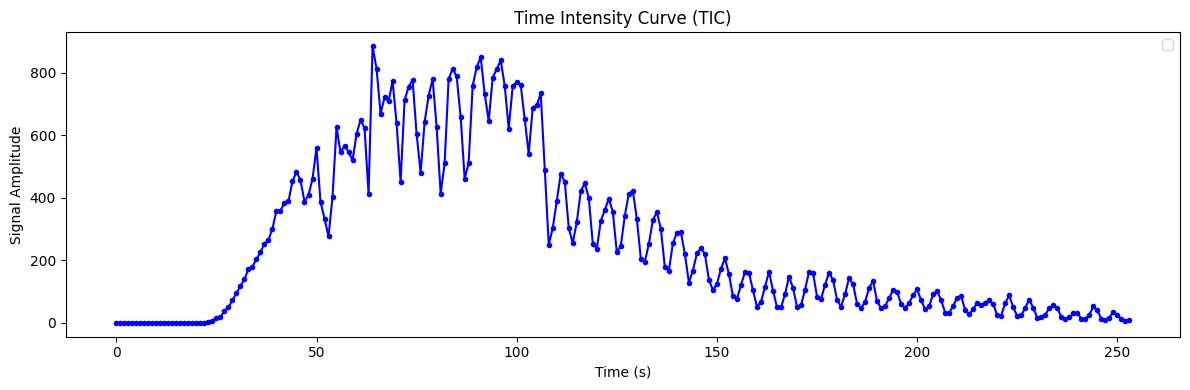

In [20]:
import matplotlib.pyplot as plt

time_arr = analysis_obj.time_arr

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_arr, tic, 'b-o', markersize=3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Signal Amplitude')
ax.set_title('Time Intensity Curve (TIC)')
ax.legend()
plt.tight_layout()
plt.show()

## Curve Quantification

In [15]:
from src.curve_quantification.options import get_quantification_funcs

quantification_funcs = get_quantification_funcs()
print("Available quantification functions:", quantification_funcs.keys())

Available quantification functions: dict_keys(['auc_no_fit', 'cmus_firstorder', 'dte', 'first_order_full', 'first_order_select', 'lognormal_fit_full', 'lognormal_fit_select', 'wash_rates'])


In [16]:
function_names = [] # Empty list will use all functions
output_path = '/Users/samantha/Desktop/tul/china data/output/curve_quant_raw.csv'
curve_quantifications_kwargs = {
    'curves_to_fit': ['TIC', 'TIC_vol'],
    'tic_name': 'TIC'
}

In [17]:
from src.entrypoints import curve_quantification_step

curve_quant = curve_quantification_step(analysis_obj, function_names, output_path, **curve_quantifications_kwargs)

In [18]:
import numpy as np
data = curve_quant.data_dict[0]
print(f"{'Parameter':<30} {'Value':>15}")
print("-" * 47)
for key, value in data.items():
    if isinstance(value, float):
        print(f"{key:<30} {value:>15.4f}")
    else:
        print(f"{key:<30} {str(value):>15}")

# Volume and depth calculation
pixdim = image_data.pixdim
voxel_vol_mm3 = np.prod(pixdim)
n_voxels = int(np.sum(seg_data.seg_mask > 0))
vol_mm3 = n_voxels * voxel_vol_mm3

img_shape = image_data.intensities_for_analysis.shape  # (sag, cor, ax, t)
scanning_depth_mm = img_shape[2] * float(pixdim[2])  # axial pixels * axial spacing

print(f"\n{'VOI Volume':<30}")
print("-" * 47)
print(f"{'Voxel spacing (mm)':<30} {str(pixdim):>15}")
print(f"{'Voxels in VOI':<30} {n_voxels:>15,}")
print(f"{'Volume (mm³)':<30} {vol_mm3:>15.1f}")
print(f"{'Volume (cm³)':<30} {vol_mm3/1000:>15.2f}")
print(f"{'Scanning depth (mm)':<30} {scanning_depth_mm:>15.1f}")
print(f"{'Scanning depth (cm)':<30} {scanning_depth_mm/10:>15.2f}")

Parameter                                Value
-----------------------------------------------
Scan Name                      CEUS-24728 S7-2.nii
Segmentation Name                       v2_voi
AUC_NoFit_TIC                          71.5525
AUC_full_TIC                        63344.4301
PE_full_TIC                           712.1352
TP_full_TIC                            74.3513
MTT_full_TIC                           98.6645
T0_full_TIC                             0.0000
Mu_full_TIC                             4.4974
Sigma_full_TIC                          0.4343
PE_Ix_full_TIC                              74
AUC_full_TIC_vol                585449668.1448
PE_full_TIC_vol                   6581783.5177
TP_full_TIC_vol                        74.3513
MTT_full_TIC_vol                       98.6645
T0_full_TIC_vol                         0.0000
Mu_full_TIC_vol                         4.4974
Sigma_full_TIC_vol                      0.4343
PE_Ix_full_TIC_vol                          74
WashIn_M

## Save Results to CSV

In [ ]:
import pandas as pd
import os
from datetime import datetime

out_path = "/Users/samantha/Desktop/tul/china data/p9/new_v2/new_paramap/fixedtic_voi.csv"

data = curve_quant.data_dict[0]
df = pd.DataFrame([data])
df["Timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

scan_col = "Scan Name"

if os.path.exists(out_path):
    existing = pd.read_csv(out_path)
    if "Timestamp" not in existing.columns:
        existing["Timestamp"] = pd.NaT
        existing.to_csv(out_path, index=False)
    df.to_csv(out_path, mode="a", header=False, index=False)
    print(f"Appended to {out_path}")
else:
    df.to_csv(out_path, index=False)
    print(f"Created {out_path}")